In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Wine_clust.csv")
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.shape

(178, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [6]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [7]:
df.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Ash_Alcanity            float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280                   float64
Proline                   int64
dtype: object

In [10]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical columns:")
print(list(categorical_columns))

print("\nNumerical columns:")
print(list(numerical_columns))

Categorical columns:
[]

Numerical columns:
['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline']


In [11]:
X = df.copy()
X.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame for easy viewing

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


### K-MEANS CLUSTERING

In [16]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

### Find Optimum K Using Elbow Method

In [17]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print("WCSS values:")
for k, value in zip(range(1, 11), wcss):
    print("K =", k, "WCSS =", value)

WCSS values:
K = 1 WCSS = 2314.0
K = 2 WCSS = 1658.7588524290952
K = 3 WCSS = 1277.928488844642
K = 4 WCSS = 1175.4283331033473
K = 5 WCSS = 1109.5127392938246
K = 6 WCSS = 1046.0023332143637
K = 7 WCSS = 981.5952326111657
K = 8 WCSS = 935.2012114738546
K = 9 WCSS = 889.8929111933176
K = 10 WCSS = 845.8952366525513


### Elbow Curve

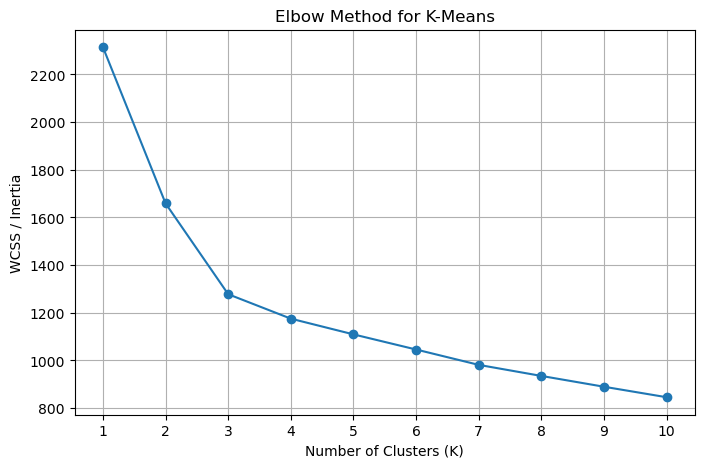

In [18]:
# Plot the Elbow Curve

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

### Silhouette Score for K-Means

In [20]:
from sklearn.metrics import silhouette_score

In [21]:
silhouette_scores = []

for k in range(2, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores.append(score)

print("Silhouette Scores:")

for k, score in zip(range(2, 11), silhouette_scores):
    print("K =", k, "Silhouette Score =", score)

Silhouette Scores:
K = 2 Silhouette Score = 0.25931695553182543
K = 3 Silhouette Score = 0.2848589191898987
K = 4 Silhouette Score = 0.26017035223704527
K = 5 Silhouette Score = 0.2016190829407409
K = 6 Silhouette Score = 0.23716725754166543
K = 7 Silhouette Score = 0.2036275812271175
K = 8 Silhouette Score = 0.1570139556393107
K = 9 Silhouette Score = 0.14988199178183517
K = 10 Silhouette Score = 0.1436384079124149


### Final K-Means Model

In [22]:

kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to the dataset

df_kmeans = df.copy()
df_kmeans["KMeans_Cluster"] = kmeans_labels

print("K-Means Cluster Counts:")
display(df_kmeans["KMeans_Cluster"].value_counts().sort_index())

K-Means Cluster Counts:


KMeans_Cluster
0    65
1    51
2    62
Name: count, dtype: int64

In [23]:
df_kmeans.head(10)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,KMeans_Cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2
5,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450,2
6,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290,2
7,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295,2
8,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045,2
9,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045,2


### HIERARCHICAL CLUSTERING

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage

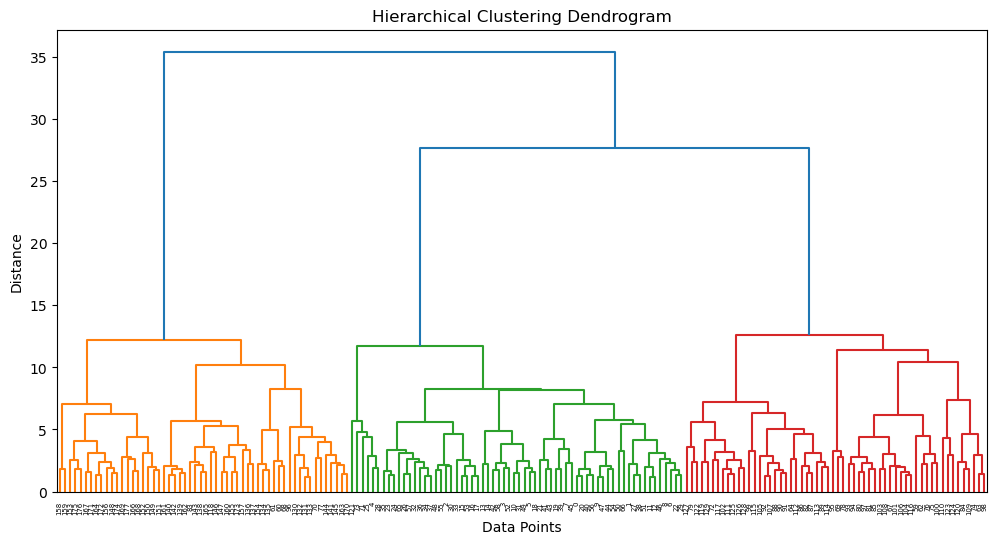

In [26]:

linked = linkage(
    X_scaled,
    method='ward'
)

# Plot dendrogram

plt.figure(figsize=(12, 6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [27]:
# Calculate silhouette score for different numbers of clusters
hierarchical_scores = []

for k in range(2, 11):
    
    hierarchical = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    
    labels = hierarchical.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    hierarchical_scores.append(score)

print("Hierarchical Clustering Silhouette Scores:")

for k, score in zip(range(2, 11), hierarchical_scores):
    print("Clusters =", k, "Silhouette Score =", score)

Hierarchical Clustering Silhouette Scores:
Clusters = 2 Silhouette Score = 0.2670131771272231
Clusters = 3 Silhouette Score = 0.2774439826952265
Clusters = 4 Silhouette Score = 0.225836659334758
Clusters = 5 Silhouette Score = 0.18674235566758707
Clusters = 6 Silhouette Score = 0.17966642854438503
Clusters = 7 Silhouette Score = 0.18685342560226942
Clusters = 8 Silhouette Score = 0.18834697102837825
Clusters = 9 Silhouette Score = 0.1917169293227209
Clusters = 10 Silhouette Score = 0.19856750165505588


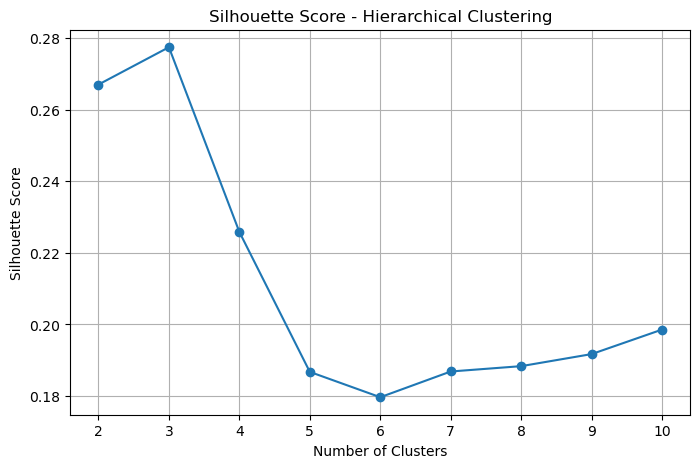

In [28]:
# Plot silhouette scores

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    hierarchical_scores,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Hierarchical Clustering")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [29]:
# Create final hierarchical clustering model

hierarchical_final = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

hierarchical_labels = hierarchical_final.fit_predict(X_scaled)

# Add cluster labels

df_hierarchical = df.copy()
df_hierarchical["Hierarchical_Cluster"] = hierarchical_labels

print("Hierarchical Cluster Counts:")
display(
    df_hierarchical["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

Hierarchical Cluster Counts:


Hierarchical_Cluster
0    58
1    56
2    64
Name: count, dtype: int64

In [30]:
# Display clustering result

print("Hierarchical Clustering Result:")
df_hierarchical.head(10)

Hierarchical Clustering Result:


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Hierarchical_Cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2
5,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450,2
6,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290,2
7,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295,2
8,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045,2
9,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045,2


### DBSCAN

In [31]:
dbscan_results = []

for eps in np.arange(0.5, 2.1, 0.1):
    
    for min_samples in [3, 4, 5, 6, 8, 10]:
        
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
        
        labels = dbscan.fit_predict(X_scaled)
        
        # Remove noise points for silhouette calculation
        mask = labels != -1
        
        if mask.sum() > 1 and len(set(labels[mask])) >= 2:
            
            score = silhouette_score(
                X_scaled[mask],
                labels[mask]
            )
            
            n_clusters = len(set(labels[mask]))
            n_noise = (labels == -1).sum()
            
            dbscan_results.append({
                "eps": round(eps, 2),
                "min_samples": min_samples,
                "clusters": n_clusters,
                "noise_points": n_noise,
                "silhouette_score": score
            })

dbscan_results_df = pd.DataFrame(dbscan_results)

print("DBSCAN parameter results:")
dbscan_results_df.sort_values(
        by="silhouette_score",
        ascending=False
    ).head(10)

DBSCAN parameter results:


,eps,min_samples,clusters,noise_points,silhouette_score
18,1.9,8,2,148,0.585595
0,1.4,3,4,165,0.533033
5,1.6,5,3,162,0.502071
9,1.7,6,3,160,0.474638
23,2.0,8,3,117,0.435964
17,1.9,6,4,119,0.434944
2,1.5,4,2,169,0.406702
8,1.7,5,6,145,0.394316
16,1.9,5,6,103,0.348993
1,1.5,3,8,147,0.331067


In [32]:
# Find the best DBSCAN parameters based on silhouette score

best_dbscan = dbscan_results_df.loc[
    dbscan_results_df["silhouette_score"].idxmax()
]

print("Best DBSCAN parameters:")
display(best_dbscan)

Best DBSCAN parameters:


eps                   1.900000
min_samples           8.000000
clusters              2.000000
noise_points        148.000000
silhouette_score      0.585595
Name: 18, dtype: float64

In [33]:
# Extract best parameters

best_eps = best_dbscan["eps"]
best_min_samples = int(best_dbscan["min_samples"])

print("Selected eps:", best_eps)
print("Selected min_samples:", best_min_samples)

# Create final DBSCAN model

dbscan_final = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

dbscan_labels = dbscan_final.fit_predict(X_scaled)

# Add cluster labels

df_dbscan = df.copy()
df_dbscan["DBSCAN_Cluster"] = dbscan_labels

print("\nDBSCAN Cluster Counts:")
display(
    df_dbscan["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
)

Selected eps: 1.9
Selected min_samples: 8

DBSCAN Cluster Counts:


DBSCAN_Cluster
-1    148
 0     22
 1      8
Name: count, dtype: int64

In [34]:
# Display DBSCAN clustering result

print("DBSCAN clustering result:")
df_dbscan.head(10)

DBSCAN clustering result:


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,DBSCAN_Cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,-1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,-1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,-1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,-1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,-1
5,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450,-1
6,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290,0
7,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295,0
8,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045,0
9,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045,0


In [35]:
# Compare the clustering models

kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

# DBSCAN silhouette excluding noise
dbscan_mask = dbscan_labels != -1

if len(set(dbscan_labels[dbscan_mask])) >= 2:
    dbscan_silhouette = silhouette_score(
        X_scaled[dbscan_mask],
        dbscan_labels[dbscan_mask]
    )
else:
    dbscan_silhouette = np.nan

comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Number of Clusters": [
        len(set(kmeans_labels)),
        len(set(hierarchical_labels)),
        len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette,
        dbscan_silhouette
    ]
})

display(comparison)

,Model,Number of Clusters,Silhouette Score
0,K-Means,3,0.284859
1,Hierarchical,3,0.277444
2,DBSCAN,2,0.585595
